## Script for statistics about binary predictions



In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
#setting filepaths the datasets

pi_results_prec_filepath = "output/PI_DataSe_precise_binary_results.csv"
#INI_results_filepath = "./INI_DataSe_results.csv"  INI did not have any results as the threshold are not set by
pi_results_sens_filepath = "output/PI_DataSe_sensitive_binary_results.csv"

nnrti_results_prec_filepath = "output/NNRTI_DataSe_precise_binary_results.csv"
nnrti_results_sens_filepath = "output/NNRTI_DataSe_sensitive_binary_results.csv"

nrti_results_prec_filepath = "output/NRTI_DataSe_precise_binary_results.csv"
nrti_results_sens_filepath = "output/NRTI_DataSe_sensitive_binary_results.csv"


ini_results_prec_filepath = "output/INI_DataSe_precise_binary_results.csv"
ini_results_sens_filepath = "output/INI_DataSe_sensitive_binary_results.csv"

#creating lists with filepaths for later visualisation
filepath_prec_list = [pi_results_prec_filepath, nnrti_results_prec_filepath, nrti_results_prec_filepath, ini_results_prec_filepath]

filepath_sens_list = [pi_results_sens_filepath, nnrti_results_sens_filepath, nrti_results_sens_filepath, ini_results_sens_filepath]



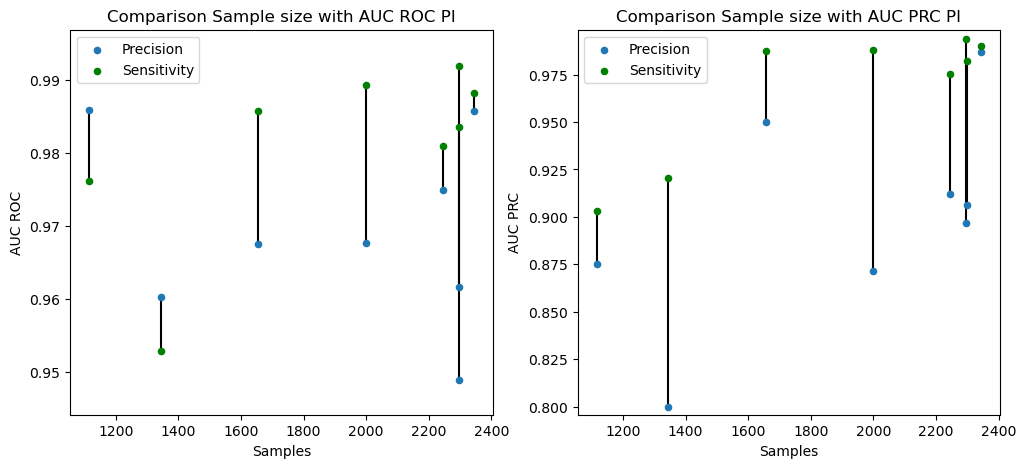

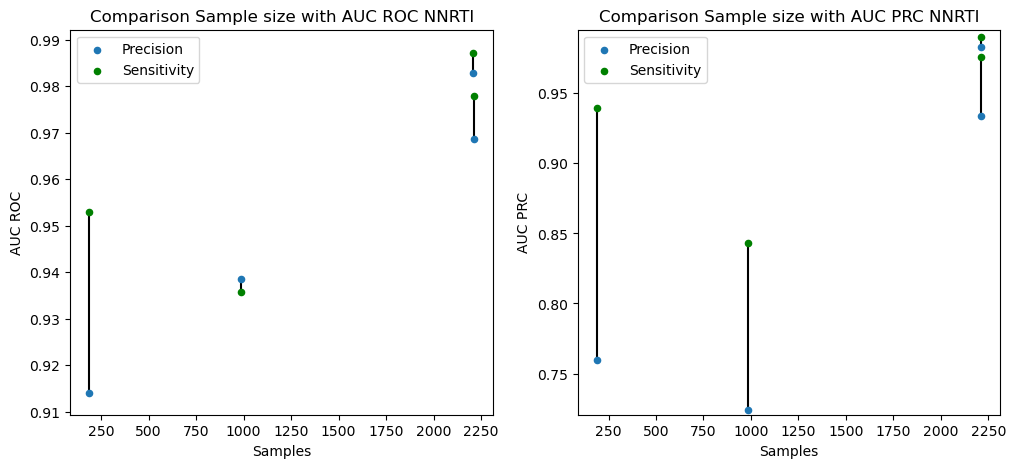

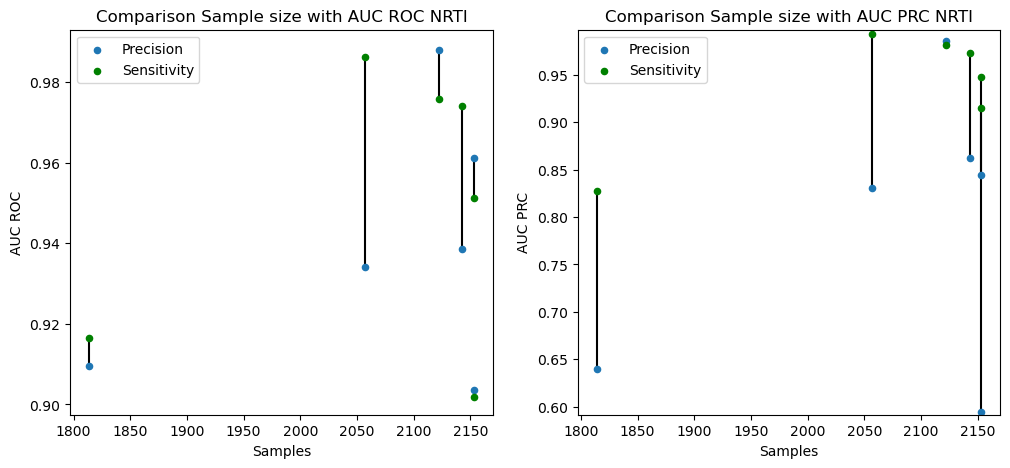

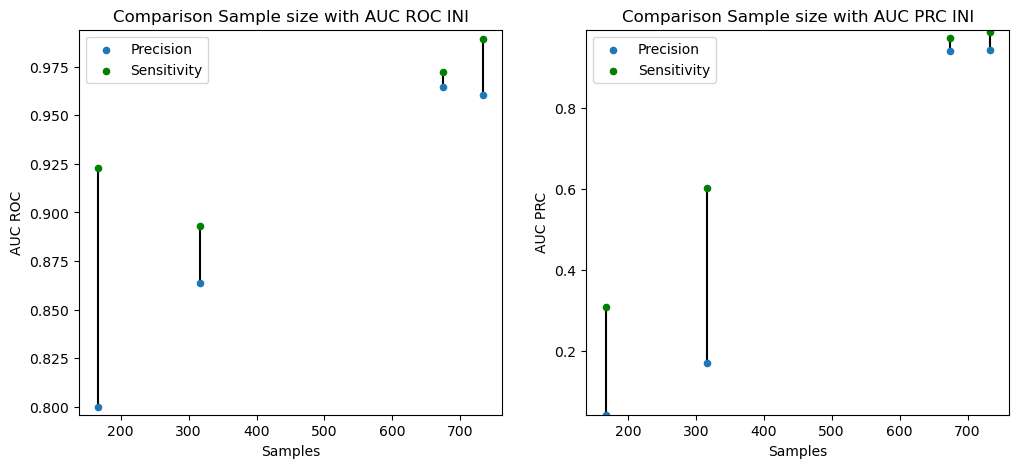

In [3]:


for filepath_prec, filepath_sens in zip(filepath_prec_list, filepath_sens_list):
    target_prec = pd.read_csv(filepath_prec)
    target_sens = pd.read_csv(filepath_sens)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    #fig.suptitle('Horizontally stacked subplots')

    axs[0].plot((target_prec["Samples"],target_sens["Samples"]),(target_prec["AUC ROC"], target_sens["AUC ROC"]),c='black', zorder=0)
    target_prec.plot.scatter(x='Samples', y='AUC ROC', ax=axs[0], label='Precision', zorder=1)
    target_sens.plot.scatter(x='Samples', y='AUC ROC', ax=axs[0], label='Sensitivity', color="g", zorder=2)
    axs[0].set_ylim(min(target_prec['AUC ROC'].min(), target_sens['AUC ROC'].min())* 0.995, min(1.0, max(target_prec['AUC ROC'].max(), target_sens['AUC ROC'].max())  * 1.005))
    axs[0].set_title('Comparison Sample size with AUC ROC ' + filepath_prec.split("/")[1].split("_")[0])

    axs[1].plot((target_prec["Samples"],target_sens["Samples"]),(target_prec["AUC PRC"], target_sens["AUC PRC"]),c='black', zorder=0)
    target_prec.plot.scatter(x='Samples', y='AUC PRC', ax=axs[1], label='Precision', zorder=1)
    target_sens.plot.scatter(x='Samples', y='AUC PRC', ax=axs[1], label='Sensitivity', color="g", zorder=2)
    axs[1].set_ylim(min(target_prec['AUC PRC'].min(), target_sens['AUC PRC'].min())* 0.995, min(1.0, max(target_prec['AUC PRC'].max(), target_sens['AUC PRC'].max())  * 1.005))
    axs[1].set_title('Comparison Sample size with AUC PRC ' + filepath_prec.split("/")[1].split("_")[0])
    plt.tight_layout
    plt.savefig("figures/" + filepath_prec.split("/")[1].split("_")[0] + "_Binary_Sample_size.png")

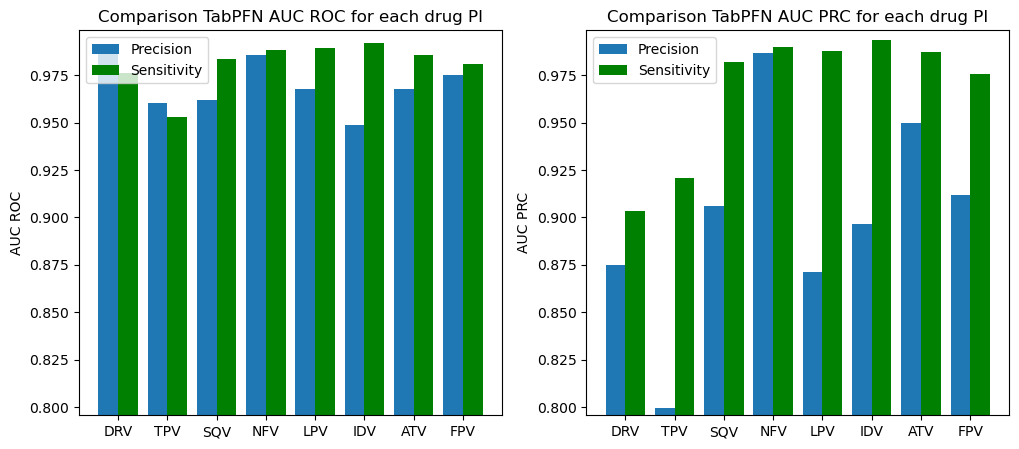

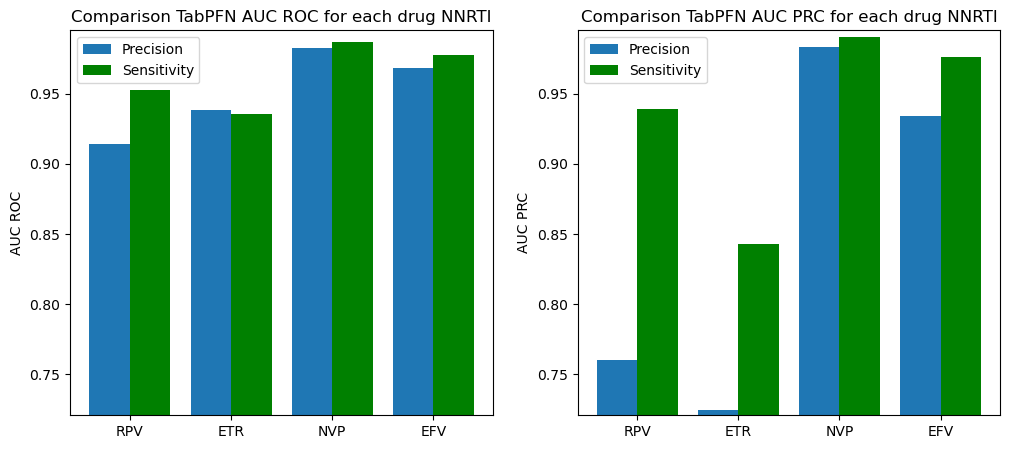

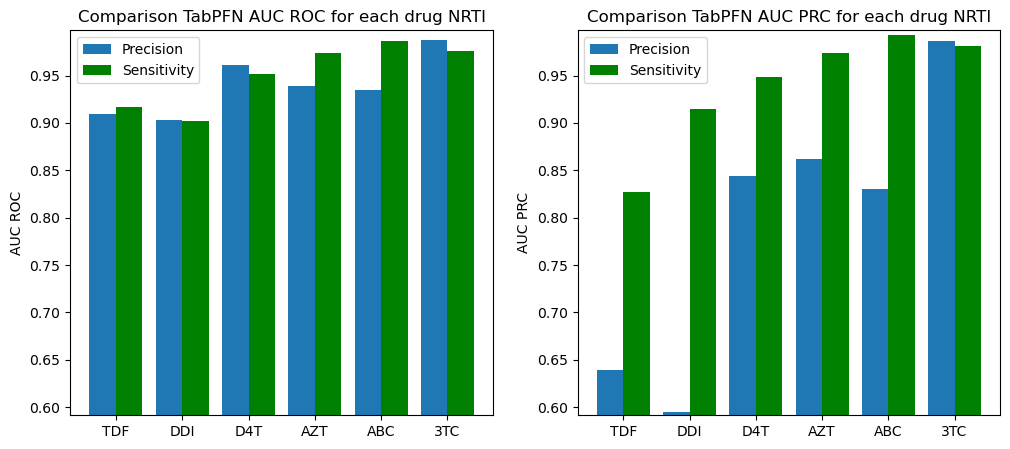

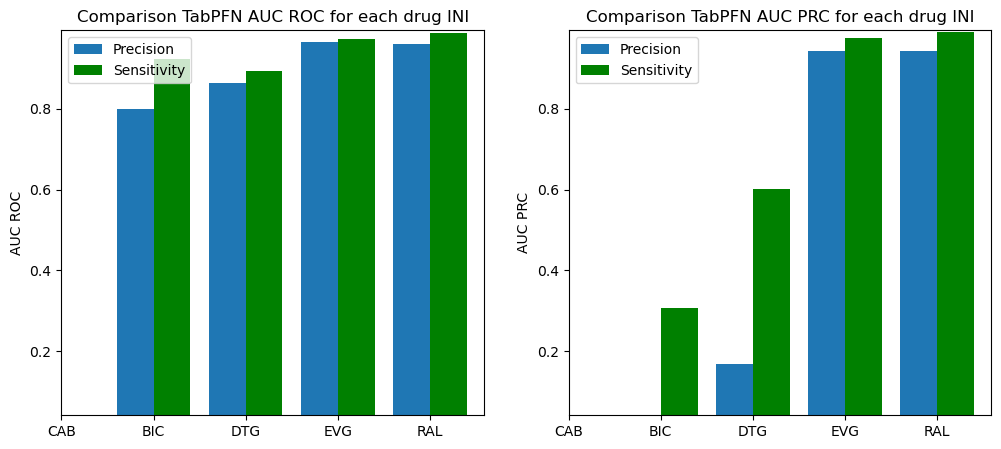

In [4]:


for filepath_prec, filepath_sens in zip(filepath_prec_list, filepath_sens_list):
    target_prec = pd.read_csv(filepath_prec)
    target_sens = pd.read_csv(filepath_sens)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    #fig.suptitle('Horizontally stacked subplots')

    w, x = 0.4, np.arange(len(target_prec["Drug"]))

    axs[0].bar(x - w/2, target_prec["AUC ROC"], width=w, label='Precision')
    axs[0].bar(x + w/2, target_sens["AUC ROC"], width=w, color="g", label='Sensitivity')

    axs[0].set_xticks(x)
    axs[0].set_xticklabels(target_prec["Drug"])
    axs[0].set_ylabel('AUC ROC')
    axs[0].set_ylim(min(target_prec['AUC ROC'].min(), target_sens['AUC ROC'].min(), target_prec['AUC PRC'].min(), target_sens['AUC PRC'].min())* 0.995, min(1.0, max(target_prec['AUC ROC'].max(), target_sens['AUC ROC'].max(), target_prec['AUC PRC'].max(), target_sens['AUC PRC'].max())  * 1.005))
    axs[0].set_title('Comparison TabPFN AUC ROC for each drug ' + filepath_prec.split("/")[1].split("_")[0])
    axs[0].legend()


    axs[1].bar(x - w/2, target_prec["AUC PRC"], width=w, label='Precision')
    axs[1].bar(x + w/2, target_sens["AUC PRC"], width=w, color="g", label='Sensitivity')

    axs[1].set_xticks(x)
    axs[1].set_xticklabels(target_prec["Drug"])
    axs[1].set_ylabel('AUC PRC')
    axs[1].set_ylim(min(target_prec['AUC ROC'].min(), target_sens['AUC ROC'].min(), target_prec['AUC PRC'].min(), target_sens['AUC PRC'].min())* 0.995, min(1.0, max(target_prec['AUC ROC'].max(), target_sens['AUC ROC'].max(), target_prec['AUC PRC'].max(), target_sens['AUC PRC'].max())  * 1.005))
    axs[1].set_title('Comparison TabPFN AUC PRC for each drug ' + filepath_prec.split("/")[1].split("_")[0])
    axs[1].legend()


    plt.savefig("figures/" + filepath_prec.split("/")[1].split("_")[0] + "_Binary_Comparison_PrecSens.png")


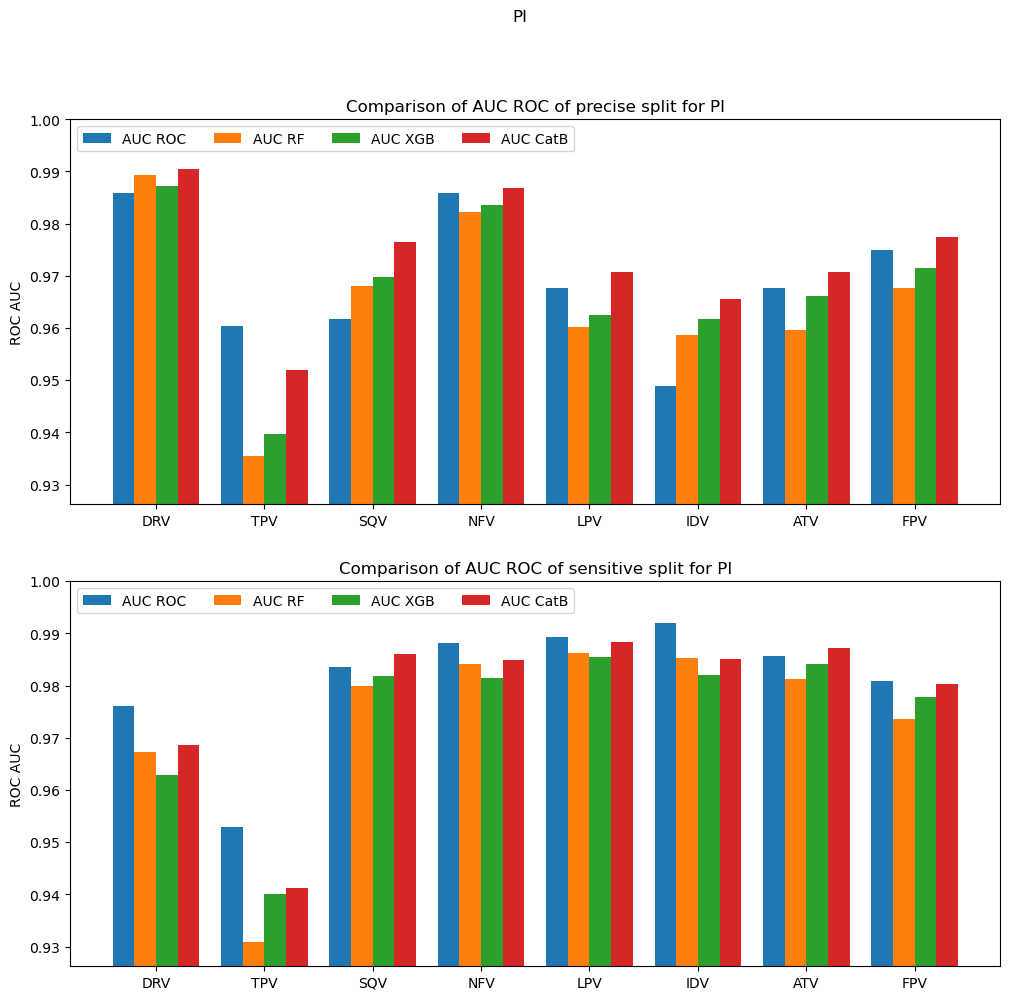

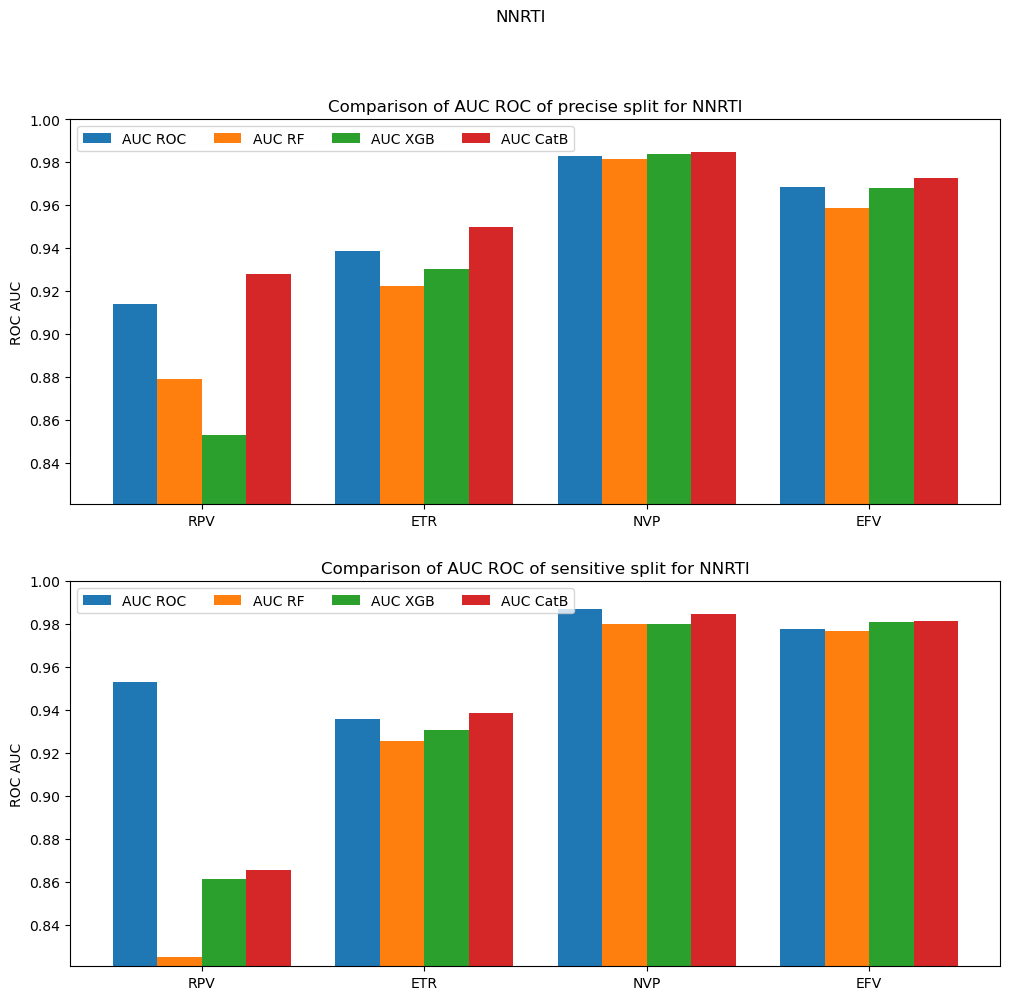

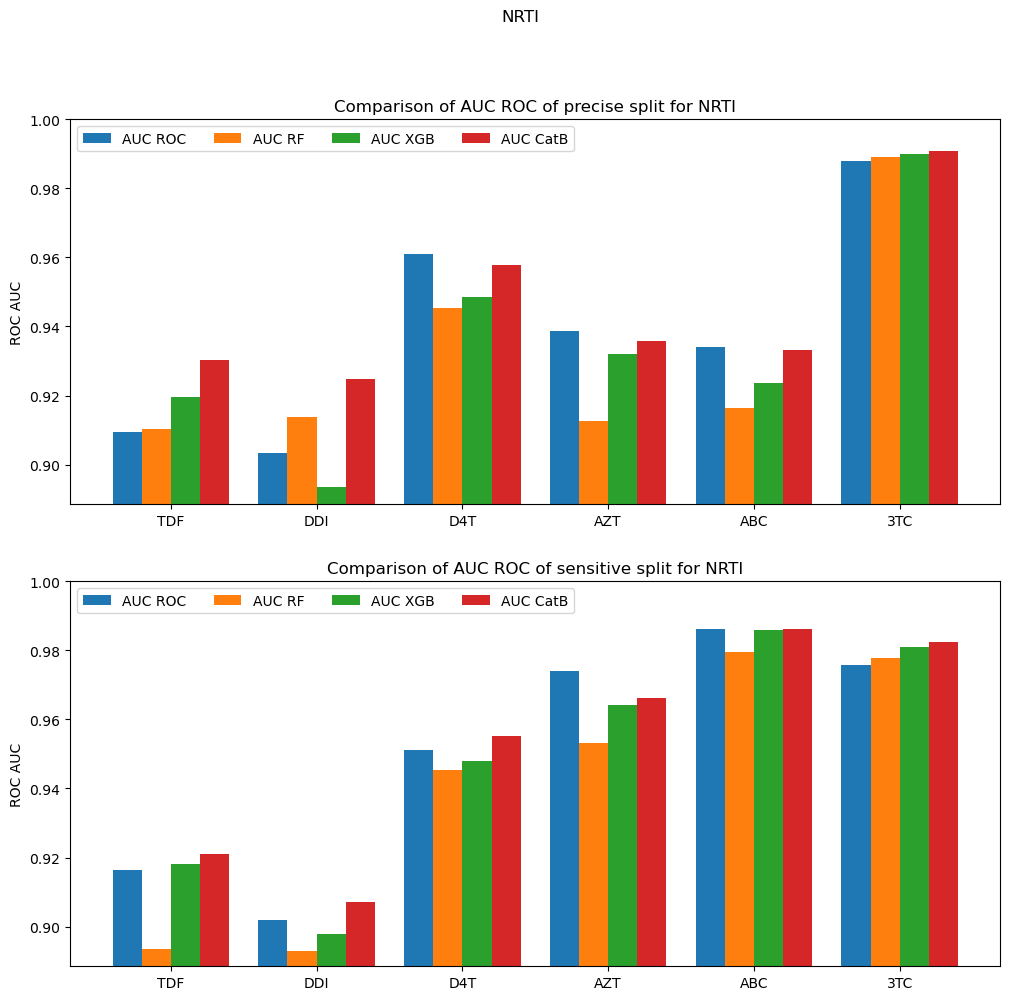

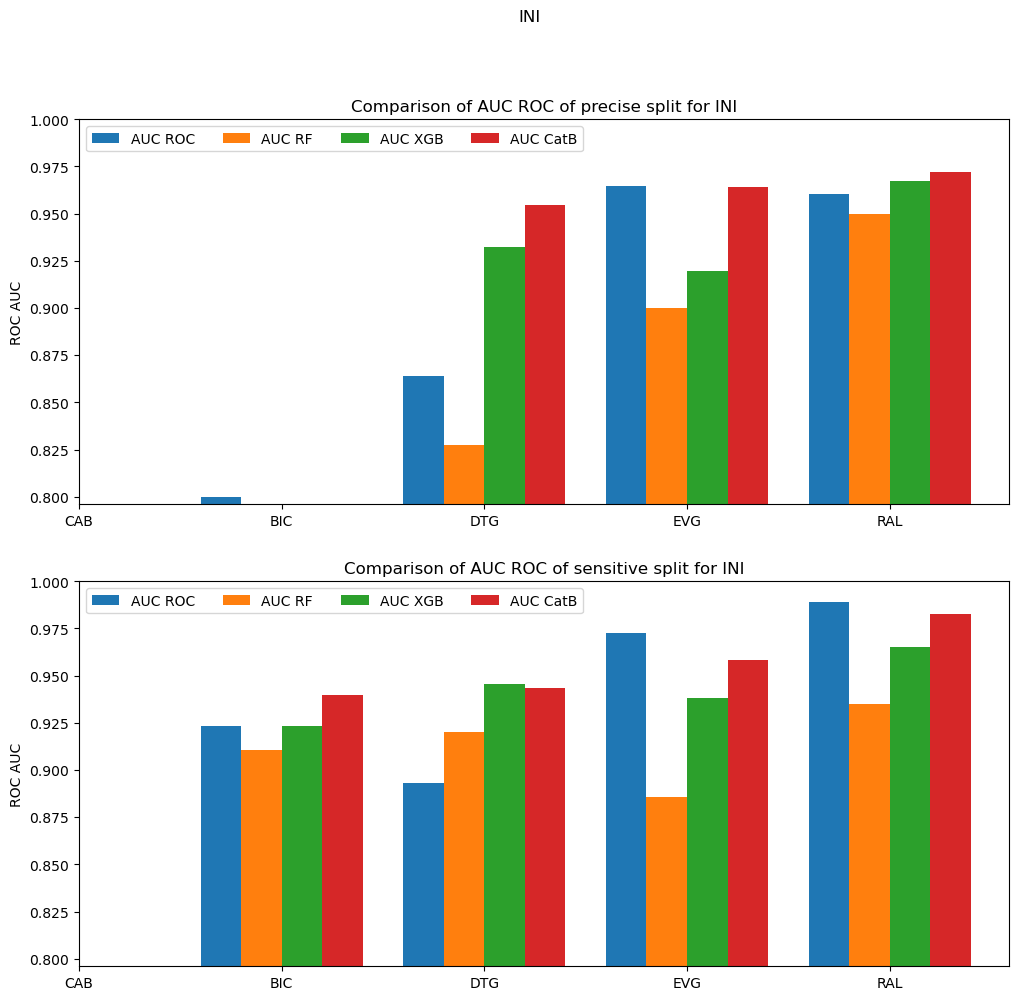

In [5]:
#Grouped bar charts, taken and modified from https://matplotlib.org/stable/gallery/lines_bars_and_markers/barchart.html

width = 0.2  # the width of the bars
multiplier = 0

for filepath_prec, filepath_sens in zip(filepath_prec_list, filepath_sens_list):
    df1 = pd.read_csv(filepath_prec)
    df2 = pd.read_csv(filepath_sens)

    target_prec = df1.copy().filter(["AUC ROC","AUC RF","AUC XGB", "AUC CatB"])
    target_sens = df2.copy().filter(["AUC ROC","AUC RF","AUC XGB", "AUC CatB"])
    #target = np.round(target, decimals=3)
    fig, axs = plt.subplots(2, figsize=(12, 11))

    fig.suptitle(filepath_prec.split("/")[1].split("_")[0])

    x = np.arange(len(target_prec))
    multiplier = 0

    min_auc = min(np.min(target_prec), np.min(target_sens))
    max_auc = max(np.max(target_prec), np.max(target_sens))

    for attribute, measurement in target_prec.items():
        offset = width * multiplier
        rects = axs[0].bar(x + offset, measurement, width, label=attribute)
        #ax.bar_label(rects, padding=3)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    axs[0].set_ylabel('ROC AUC')
    axs[0].set_title('Comparison of AUC ROC of precise split for ' + filepath_prec.split("/")[1].split("_")[0])
    axs[0].set_xticks(x + width * (multiplier - 1) / 2)
    axs[0].set_xticklabels(df1.Drug)
    axs[0].legend(loc='upper left', ncols=4)
    axs[0].set_ylim(min_auc * 0.995, min(1.0, max_auc * 1.02))

    multiplier = 0

    for attribute, measurement in target_sens.items():
        offset = width * multiplier
        rects = axs[1].bar(x + offset, measurement, width, label=attribute)
        #ax.bar_label(rects, padding=3)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    axs[1].set_ylabel('ROC AUC')
    axs[1].set_title('Comparison of AUC ROC of sensitive split for ' + filepath_sens.split("/")[1].split("_")[0])
    axs[1].set_xticks(x + width * (multiplier - 1) / 2)
    axs[1].set_xticklabels(df2.Drug)
    axs[1].legend(loc='upper left', ncols=4)
    axs[1].set_ylim(min_auc * 0.995, min(1.0, max_auc * 1.02))



    '''
    ax = target.plot.bar(x='Drug', y='AUC ROC', figsize=(10, 6))
    ax.set_ylim(target['AUC ROC'].min() * 0.995, min(1.0, target['AUC ROC'].max() * 1.005))
    ax.set_title('Comparison Sample size with AUC for ' + filepath.split("/")[1].strip("_DataSe_results.csv"))
    '''

    plt.savefig("figures/" + filepath_prec.split("/")[1].split("_")[0] + "_Binary_Other_methods.png")
